In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [51]:
models ={
    'Oracle-1 Lite': ['../../models/Shah25b_Oracle1-lite/',],
    'Oracle-1': ['../../models/Shah25b_Oracle1/',],
    'Oracle-2 Lite': [],
    'Oracle-2': ['../../models/ELAsTiCCv2/devout-sweep-4/',],

}

colors = {
    'Oracle-2 Lite': '#994882',
    'Oracle-2': '#008080',
    'Oracle-1 Lite': "#6A6A6A",
    'Oracle-1': "#000000",
}

markers = {
    'Oracle-2 Lite': 's',
    'Oracle-2': 'D',
    'Oracle-1 Lite': 'o',
    'Oracle-1': '^',
}

linestyles = {
    'Oracle-2 Lite': 'solid',
    'Oracle-2': 'solid',
    'Oracle-1 Lite': 'dashed',
    'Oracle-1': 'dashed',
}

In [52]:
days = 2**np.arange(0, 11)

In [53]:
def get_data(model_path, c, stat, depth, days=days):

    data = []

    for day in days:

        if model_path in models['Oracle-1 Lite'] or model_path in models['Oracle-1']:
            path = f"{model_path}/level_{depth}_csv/Trigger + {day} days.csv"
            df = pd.read_csv(path)
            df.rename(columns={df.columns[0]: "Class"}, inplace=True)
        else:
            path = f"{model_path}/reports/depth{depth}/report_trigger+{day}.csv"
            df = pd.read_csv(path)
        df_class = df[df['Class'] == c]
        value = df_class[stat].values[0]
        data.append(value)

    return np.array(data)
        

In [54]:
def get_model_stats(model_name, c, stat, depth, days=days):

    model_paths = models[model_name]
    model_data = np.zeros((len(model_paths), len(days))) 

    for i, model_path in enumerate(model_paths):
        print(f"Processing model: {model_name}, path: {model_path}")
        model_data[i,:] = get_data(model_path, c, stat, depth, days)

    return np.mean(model_data, axis=0), np.std(model_data, axis=0)


In [59]:
def plot_model_stats_multi_level(c, stat):

    # make the plots next to each other for depth in [1, 2]:
    plt.figure(figsize=(16, 4))
    for i, depth in enumerate([1, 2, -1]):

        plt.subplot(1, 3, i+1)
        for model_name in models.keys():

            if model_name == 'Oracle-2 Lite':
                continue

            mean_f1, std_f1 = get_model_stats(model_name, c, stat, depth)

            plt.plot(days, mean_f1, label=model_name, linestyle=linestyles[model_name],color=colors[model_name], marker=markers[model_name], markeredgecolor='white', markersize=8)
            plt.fill_between(days, mean_f1 - std_f1, mean_f1 + std_f1, color=colors[model_name], alpha=0.2)


        plt.xscale('log')
        plt.grid(True, alpha=0.3)
        plt.xticks(days, labels=days)
        plt.xlabel('Days since first detection', fontsize='xx-large' )
        plt.ylabel(stat, fontsize='xx-large')

        # make a background box for the text
        plt.gca().text(0.875, 0.05, f'Depth {depth}', transform=plt.gca().transAxes, ha='center', fontsize='x-large', bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # Get handles and labels from the last axis to use in the figure legend
    handles, labels = plt.gca().get_legend_handles_labels()
    
    # Use fig.legend for centering across the whole figure
    fig = plt.gcf()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(models), fontsize='x-large')
    
    # Adjust tight_layout to leave room for the legend at the bottom
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    plt.savefig(f"Elasticc_F1.pdf", bbox_inches='tight')
    plt.show()

Processing model: Oracle-1 Lite, path: ../../models/Shah25b_Oracle1-lite/
Processing model: Oracle-1, path: ../../models/Shah25b_Oracle1/
Processing model: Oracle-2, path: ../../models/ELAsTiCCv2/devout-sweep-4/
Processing model: Oracle-1 Lite, path: ../../models/Shah25b_Oracle1-lite/
Processing model: Oracle-1, path: ../../models/Shah25b_Oracle1/
Processing model: Oracle-2, path: ../../models/ELAsTiCCv2/devout-sweep-4/
Processing model: Oracle-1 Lite, path: ../../models/Shah25b_Oracle1-lite/
Processing model: Oracle-1, path: ../../models/Shah25b_Oracle1/
Processing model: Oracle-2, path: ../../models/ELAsTiCCv2/devout-sweep-4/


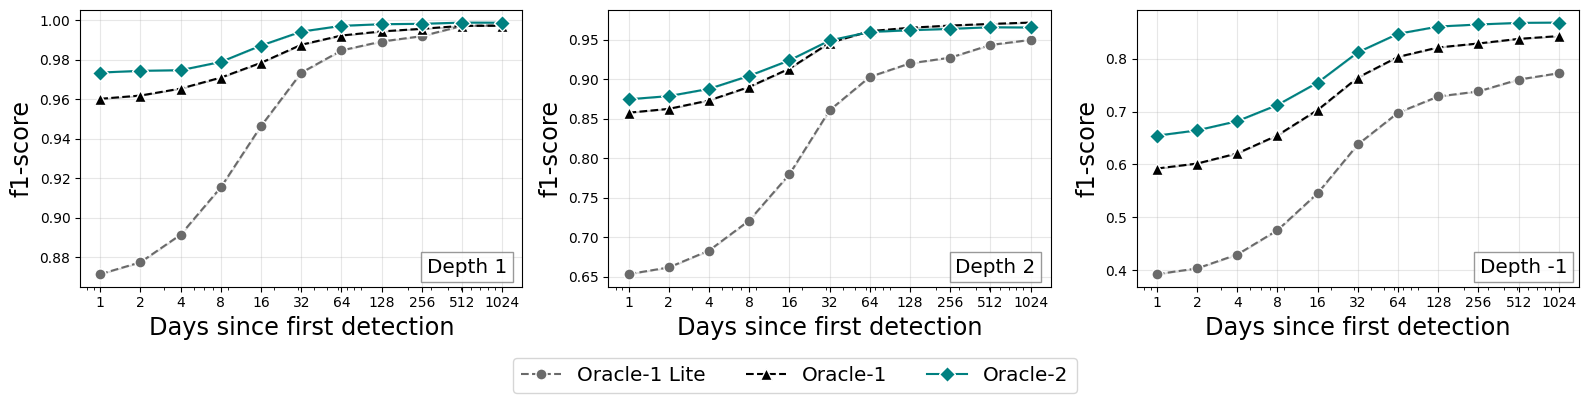

In [60]:
plot_model_stats_multi_level('macro avg', 'f1-score')

In [20]:
def plot_model_stats(c, stat, depth):

    plt.figure(figsize=(10, 6))
    for model_name in models.keys():

        if model_name == 'Oracle-2 Lite' or model_name == 'Oracle-2 Omni':
            continue

        mean_f1, std_f1 = get_model_stats(model_name, c, stat, depth)

        plt.plot(days, mean_f1, label=model_name, color=colors[model_name], marker=markers[model_name])
        plt.fill_between(days, mean_f1 - std_f1, mean_f1 + std_f1, color=colors[model_name], alpha=0.2)

    plt.xscale('log')
    plt.grid(True, alpha=0.3)
    plt.xticks(days, labels=days)
    plt.xlabel('Days')
    plt.ylabel(stat)
    plt.title(f'{stat} for class {c} at depth {depth}')
    plt.legend()
    plt.show()

Processing model: Image Backbone, path: ../../models/BTSv2_PSonly/stoic-sweep-6
Processing model: Oracle-2, path: ../../models/BTSv2/peachy-sweep-4
Processing model: Oracle-2, path: ../../models/BTSv2/rare-night-119
Processing model: Oracle-2, path: ../../models/BTSv2/winter-meadow-120
Processing model: Oracle-2, path: ../../models/BTSv2/rural-tree-121
Processing model: Oracle-2, path: ../../models/BTSv2/resilient-feather-125


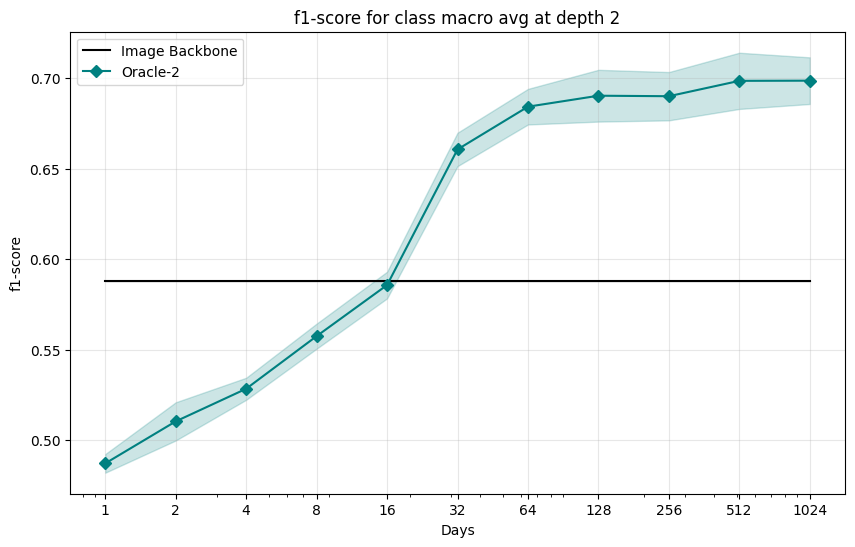

In [21]:
plot_model_stats('macro avg', 'f1-score', 2)

Processing model: Image Backbone, path: ../../models/BTSv2_PSonly/stoic-sweep-6
Processing model: Oracle-2, path: ../../models/BTSv2/peachy-sweep-4
Processing model: Oracle-2, path: ../../models/BTSv2/rare-night-119
Processing model: Oracle-2, path: ../../models/BTSv2/winter-meadow-120
Processing model: Oracle-2, path: ../../models/BTSv2/rural-tree-121
Processing model: Oracle-2, path: ../../models/BTSv2/resilient-feather-125


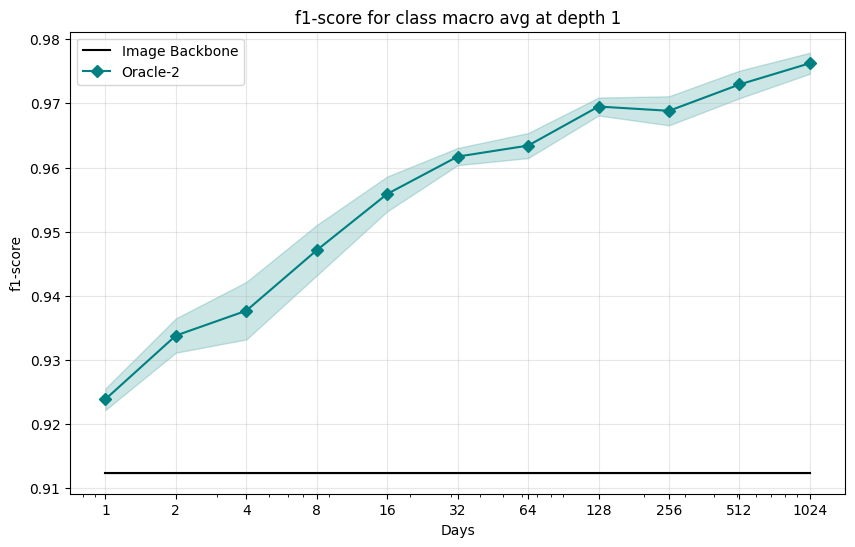

In [22]:
plot_model_stats('macro avg', 'f1-score', 1)

Processing model: Image Backbone, path: ../../models/BTSv2_PSonly/stoic-sweep-6
Processing model: Oracle-2, path: ../../models/BTSv2/peachy-sweep-4
Processing model: Oracle-2, path: ../../models/BTSv2/rare-night-119
Processing model: Oracle-2, path: ../../models/BTSv2/winter-meadow-120
Processing model: Oracle-2, path: ../../models/BTSv2/rural-tree-121
Processing model: Oracle-2, path: ../../models/BTSv2/resilient-feather-125


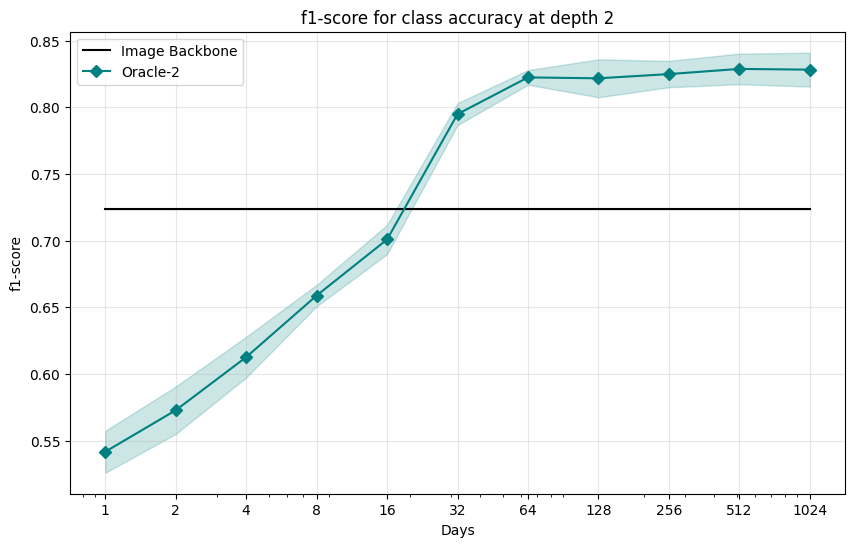

In [23]:
plot_model_stats('accuracy', 'f1-score', 2)